## GoogLeNet (Inception v1)

**GoogLeNet** là một kiến trúc mạng nơ-ron tích chập sâu (CNN) được đề xuất bởi Google trong bài báo *“Going Deeper with Convolutions”* và đã giành chiến thắng tại cuộc thi ImageNet 2014. Điểm nổi bật của GoogLeNet là việc giới thiệu **Inception Module**, cho phép mạng học các đặc trưng ở nhiều tỷ lệ (multi-scale) bằng cách kết hợp song song các phép tích chập 1×1, 3×3, 5×5 và pooling trong cùng một khối.

Một cải tiến quan trọng của mô hình là sử dụng **convolution 1×1** như một lớp "bottleneck" để giảm số chiều (số kênh) trước khi áp dụng các kernel lớn hơn, từ đó giảm đáng kể chi phí tính toán. Ngoài ra, GoogLeNet còn sử dụng **auxiliary classifiers** ở các tầng trung gian nhằm cải thiện quá trình lan truyền gradient và giảm hiện tượng vanishing gradient khi huấn luyện mạng sâu.

Khác với các kiến trúc trước đó như VGG, GoogLeNet loại bỏ các fully connected layer lớn và thay bằng **Global Average Pooling**, giúp giảm số lượng tham số và hạn chế overfitting. Nhờ những cải tiến này, GoogLeNet đạt được hiệu suất cao với số tham số ít hơn đáng kể so với các mô hình cùng thời.

Tóm lại, GoogLeNet là một bước tiến quan trọng trong việc thiết kế mạng CNN sâu, với các ý tưởng cốt lõi gồm: xử lý đa tỷ lệ (Inception), giảm chiều bằng 1×1 convolution, và tối ưu hóa kiến trúc để vừa hiệu quả vừa tiết kiệm tài nguyên.

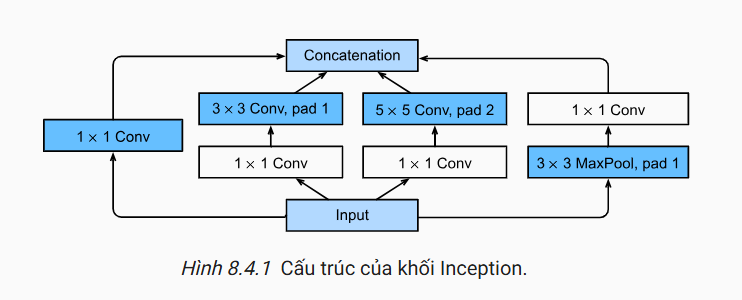

In [1]:
import torch
from torch import nn
from torch.nn import functional as F

class Inception(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        # Branch 1
        self.b1_1 = nn.LazyConv2d(c1, kernel_size=1)
        # Branch 2
        self.b2_1 = nn.LazyConv2d(c2[0], kernel_size=1)
        self.b2_2 = nn.LazyConv2d(c2[1], kernel_size=3, padding=1)
        # Branch 3
        self.b3_1 = nn.LazyConv2d(c3[0], kernel_size=1)
        self.b3_2 = nn.LazyConv2d(c3[1], kernel_size=5, padding=2)
        # Branch 4
        self.b4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.b4_2 = nn.LazyConv2d(c4, kernel_size=1)

    def forward(self, x):
        b1 = F.relu(self.b1_1(x))
        b2 = F.relu(self.b2_2(F.relu(self.b2_1(x))))
        b3 = F.relu(self.b3_2(F.relu(self.b3_1(x))))
        b4 = F.relu(self.b4_2(self.b4_1(x)))
        return torch.cat((b1, b2, b3, b4), dim=1)

In [3]:
class GoogleNet(nn.Module):
    def b1(self):
        return nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),
            nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
    
    def b2(self):
        return nn.Sequential(
            nn.LazyConv2d(64, kernel_size=1), nn.ReLU(),
            nn.LazyConv2d(192, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
    
    def b3(self):
        return nn.Sequential(Inception(64, (96, 128), (16, 32), 32),
                            Inception(128, (128, 192), (32, 96), 64),
                            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
    
    def b4(self):
        return nn.Sequential(Inception(192, (96, 208), (16, 48), 64),
                            Inception(160, (112, 224), (24, 64), 64),
                            Inception(128, (128, 256), (24, 64), 64),
                            Inception(112, (144, 288), (32, 64), 64),
                            Inception(256, (160, 320), (32, 128), 128),
                            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))
    
    def b5(self):
        return nn.Sequential(Inception(256, (160, 320), (32, 128), 128),
                            Inception(384, (192, 384), (48, 128), 128),
                            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten())
    

    def __init__(self, num_classes=10):
        super(GoogleNet, self).__init__()
        self.net = nn.Sequential(self.b1(), self.b2(), self.b3(), self.b4(),
                                self.b5(), nn.LazyLinear(num_classes))
        
    def layer_summary(self, X_shape):
        X = torch.randn(X_shape)
        for layer in self.net:
            X = layer(X)
            print(layer.__class__.__name__, 'output shape:\t', X.shape)

In [4]:
model = GoogleNet()
model.layer_summary((1, 1, 96, 96))

Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 192, 12, 12])
Sequential output shape:	 torch.Size([1, 480, 6, 6])
Sequential output shape:	 torch.Size([1, 832, 3, 3])
Sequential output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])
